# Linear reconstruction for DWI data

I created a dataset including the DWI data for a single subject, at 1.17mm resolution.  
The dataset includes both raw and denoised data using NORDIC. There are several ways that  
NORDIC denoising can be run, and I prepared a few different variations here. For example,  
we can run NORDIC with and without the phase correction step.  Without phase correction,  
the results are noisier but maybe more suitable for SSDU.

Each dataset also includes Spli-Slice GRAPPA (SPSG) reconstructions we can use as comparison with ours.  
There is a version of this prepared at R = 2, and another with the corresponding data but retrospectively  
undersampled to R = 4. You can look at the R = 4 version by setting accelaration = 4. I also included  
pre-prepared ESPIRIT maps and SPIRIT kernels, with which we can run CG-SENSE and CG-SPIRIT.   

This is mostly relevant to me, but I included these data constructed using both the fully sampled acs data (GRE), and using a  
single-band (SB) GRAPPA reconstruction of EPI data. Sometimes using the maps and kernels from the EPI data is better, but not  
always so I wanted to have both available. In this case it seems the maps from GRE data are better, so that is what I set up  
in this notebook. The ones from the GRE data are labeled "ACS", the ones from the EPI data are labeled "SB".

Here I included a brief overview of how to read the dataset, and perform basic linear reconstruction with CG-SENSE. 
For notation, I will use:
- nq = number of q samples
- mb = multi-band factor
- ns = number of slice groups (We also refer to slice groups as "slabs")
- nc = number of coil channels
- nx = size of phase encoding dimension
- ny = size of frequency encoding dimension
- nz = number of aquired slices (nz = mb * ns)

The dataset has many field, and most of these are things I still want to test. But most are not super important. The most import fields are  
- ksp_mb (ns, nq, nc, nx, ny) : The raw multi-band kspace / qspace data. It is already masked according to the chosen acceleration factor

- nordic_ksp (ns, nq, nc, nx, ny) : Pre-recon NORDIC denoised version of the undersampled multi-band kspace.

- nordic_nophasecor_ksp (ns, nq, nc, nx, ny) : Pre-recon NORDIC denoised version of the undersampled multi-band kspace, WITHOUT phase correction

- spsg_recon : (ns, nq, mb, nc, nx, ny) : SPSG reconstruction of the kspace data. This is the "standard" method and can be used as comparison with CG-SENSE

- spsg_recon_coilcomb : (ns, nq, mb, nx, ny) : Coil-combined SPSG reconstruction of the kspace data. Faster to read if we don't need individual coils

- nordic_spsg_coilcomb : (ns, nq, mb, nx, ny) : NORDIC denoised version of coil-combined SPSG recon.

- nordic_nophasecor_spsg_coilcomb : (ns, nq, mb, nx, ny) : Post-recon NORDIC denoised version of coil-combined SPSG recon WITHOUT phase correction

- sb_maps (ns, mb, nc, nx, ny) : Coil sensitivity maps from ESPIRIT created from GRAPPA recon of single-band EPI data. These do not have q dimension

- fov_shifts : This is a list with the FOV shift pattern for the multi-band data. Each entry corresponds to the fraction of the PE FOV that has been shifted for each MB slice




In [7]:
import os
import h5py
from pathlib import Path
from utils import *

os.environ["CUDA_VISIBLE_DEVICES"] = "3" 

device = "cuda" #"cpu"

res = "1pt17"
subj = 2
acceleration = 2
mb_factor = 5
base_dir = Path("/home/naxos2-raid40/avela019/rafael_data/fMRI_2026/dwi_data_v2")
base_dir.mkdir(exist_ok=True, parents=True)
save_file = base_dir / f"dwi_{res}_MB{mb_factor}R{acceleration}_subj{subj}.h5"

# A dictionary with the indices of the q-space samples corresponding to a each b-value
# We have three possible b-values: 0, 1500 and 3000
b_seg = {
0:     list(range(0, 7)),
1500:  list(range(7, 53)),
3000:  list(range(53, 99)),
"all": list(range(99))
}

# I am reading all qspace samples, but just a single slab (slab index 10), which includes 5 simoutaneously excited slices
b = "all"
slab_idx = 10

with h5py.File(save_file, 'r') as f:
    print(f.keys())
    spsg = f["spsg_recon_coilcomb"][slab_idx, b_seg[b], ...]
    denoised_spsg = f["nordic_spsg_coilcomb"][slab_idx, b_seg[b], ...]
    denoised_spsg_nophasecor = f["nordic_nophasecor_spsg_coilcomb"][slab_idx, b_seg[b], ...]
    ksp = f["ksp_mb"][slab_idx, b_seg[b], ...]
    denoised_ksp = f["nordic_ksp"][slab_idx, b_seg[b], ...]
    denoised_ksp_nophasecor = f["nordic_nophasecor_ksp"][slab_idx, b_seg[b], ...]
    maps = f["acs_maps"][slab_idx]
    fov_shifts = f.attrs["fov_shifts"]
    size = f["spsg_recon_coilcomb"].shape
    spirit_kernels = f["spirit_kernels_acs"][slab_idx]

print("Data size is (ns, nq, mb, nc, nx, ny) = ", size)


<KeysViewHDF5 ['acs', 'acs_maps', 'acs_sb', 'acs_singvals', 'gfactor_coilcomb_maps', 'gfactor_maps', 'ksp_mb', 'ksp_sb', 'noise_scan', 'nordic_ksp', 'nordic_nophasecor_ksp', 'nordic_nophasecor_spsg_coilcomb', 'nordic_spsg_coilcomb', 'sb_maps', 'sb_singvals', 'spirit_kernels_acs', 'spirit_kernels_sb', 'spsg_recon', 'spsg_recon_coilcomb']>
Data size is (ns, nq, mb, nc, nx, ny) =  (24, 99, 5, 134, 180)


# SPSG recons with post-recon NORDIC 

Here we take a look at the coil-combined SPSG reconstructions with and without denoising, with and without phase correction

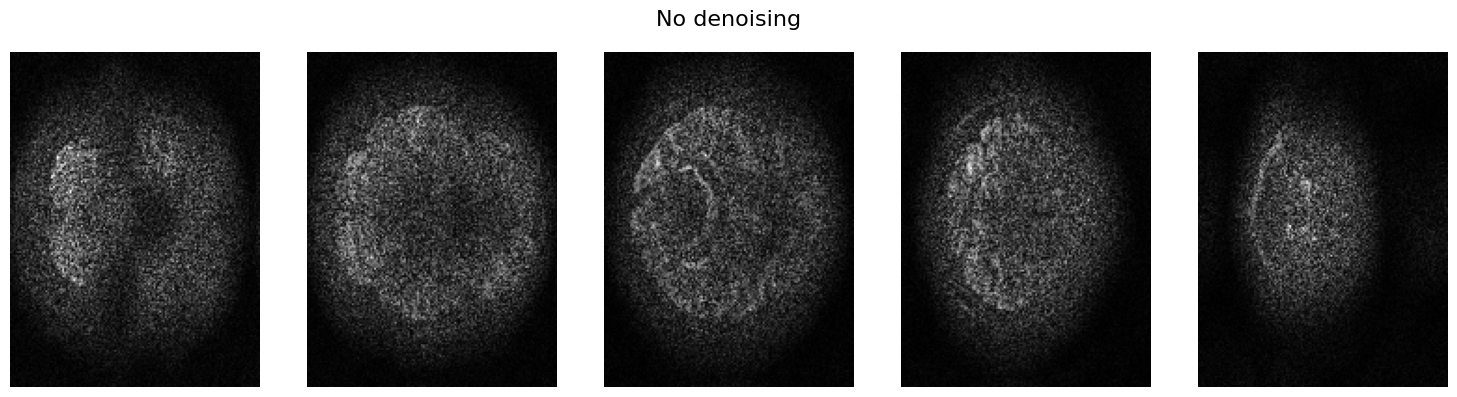

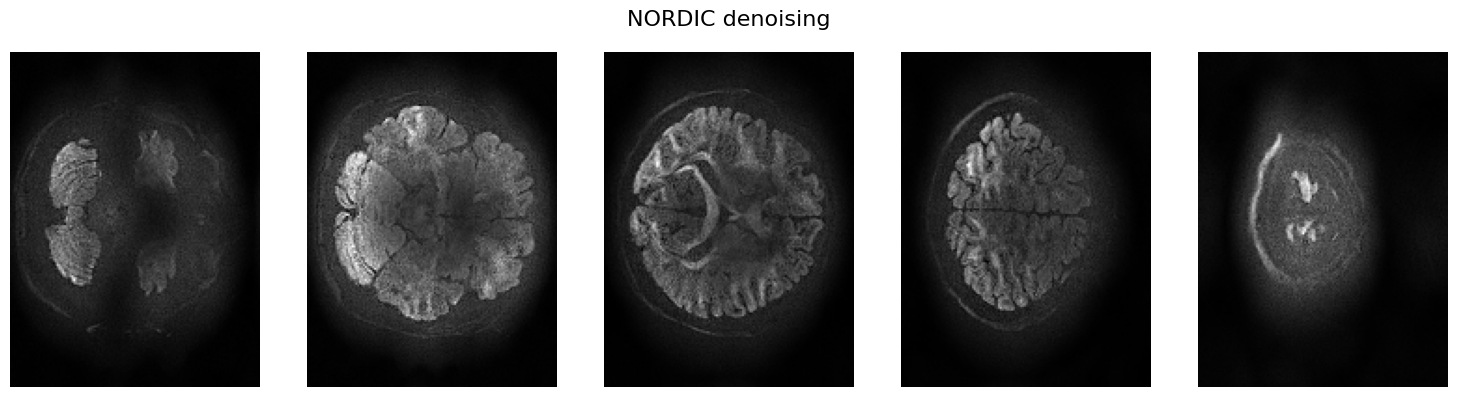

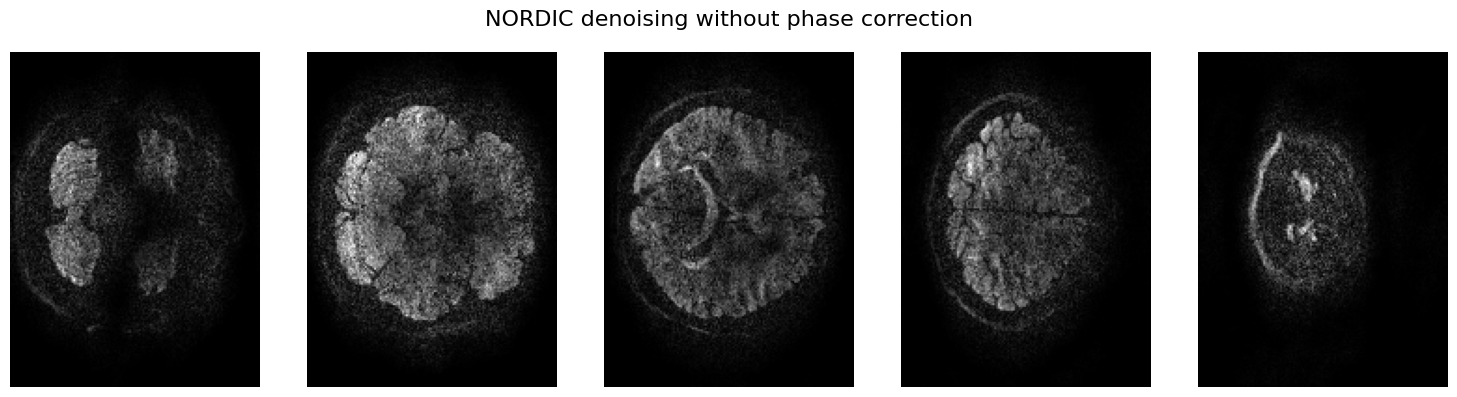

In [8]:
q_idx = 98 #Corresponding to b = 3000

img_list = [spsg, denoised_spsg, denoised_spsg_nophasecor] 
title_list = ["No denoising", "NORDIC denoising", "NORDIC denoising without phase correction"]

for img, title in zip(img_list, title_list):
    img = np.abs(img[q_idx,:,:,:])
    img = shift_fov(img, -fov_shifts, xp = np) #Remove the FOV shifts
    quick_plot(img, gs = (1,5), title = title, fs = 16)

# Aliased coil images with pre-recon NORDIC

Now, we look at the aliased coil images with and without denoising, with and without phase correction

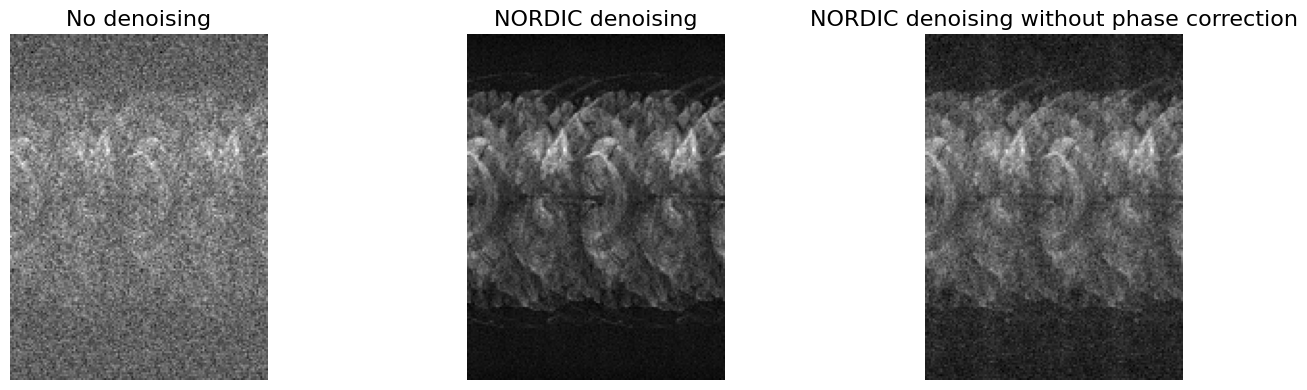

In [9]:
ksp_list = [ksp, denoised_ksp, denoised_ksp_nophasecor] 
title_list = ["No denoising", "NORDIC denoising", "NORDIC denoising without phase correction"]
plot_list = []
for img, title in zip(ksp_list, title_list):
    img = rssq(ifft_np(img[q_idx]), xp = np)
    plot_list.append(img)

quick_plot(plot_list, title_list=title_list, fs = 16)

# CG-SENSE recons with pre-recon NORDIC

We now try running CG-SENSE on this slab and plotting the results. Note that I am using a very small number of iterations (only 4!)  
More iterations amplifies noise (in the not-denoised case) and amplifies phase errors (in the denoised case)

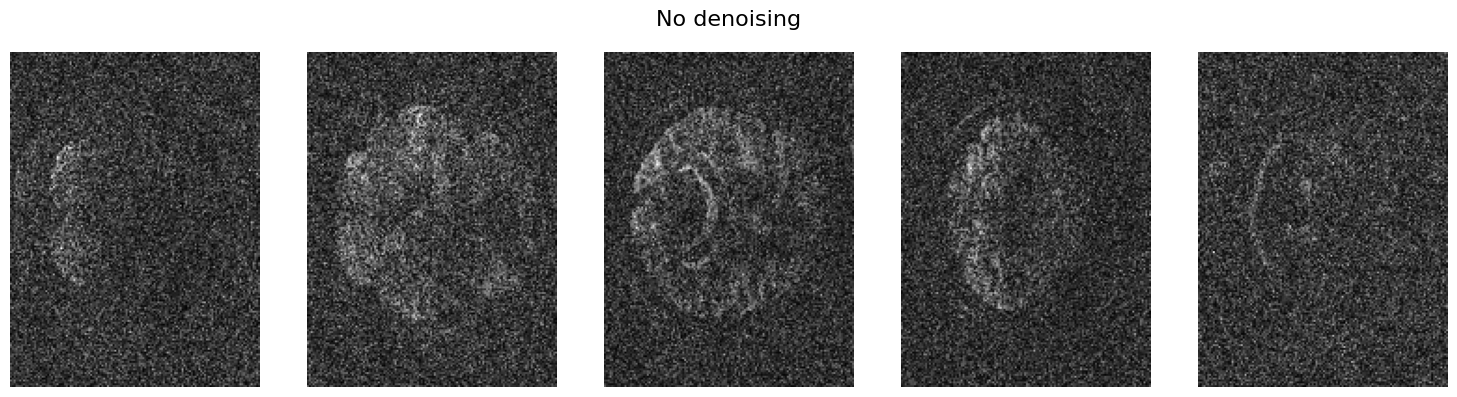

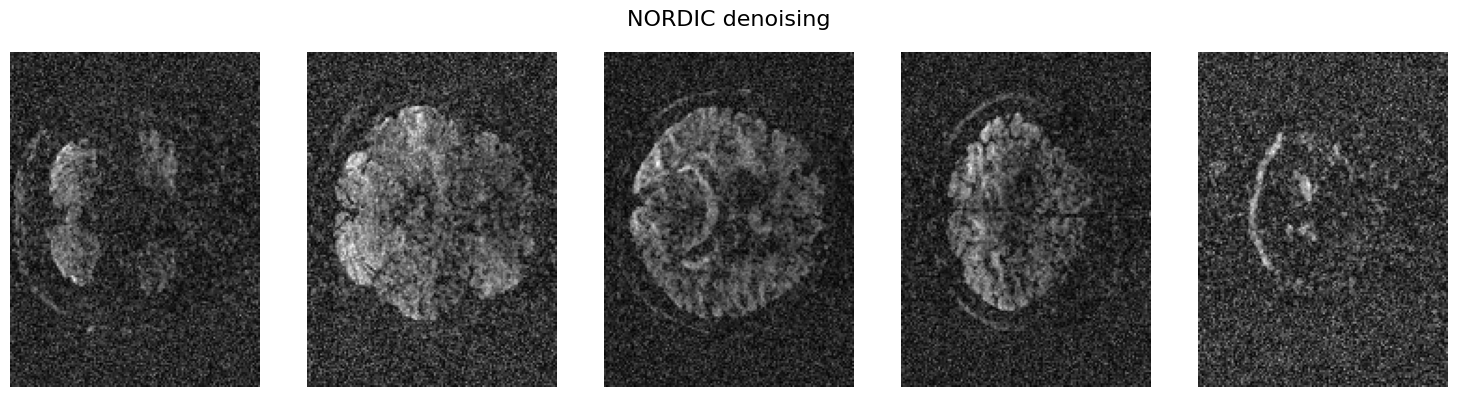

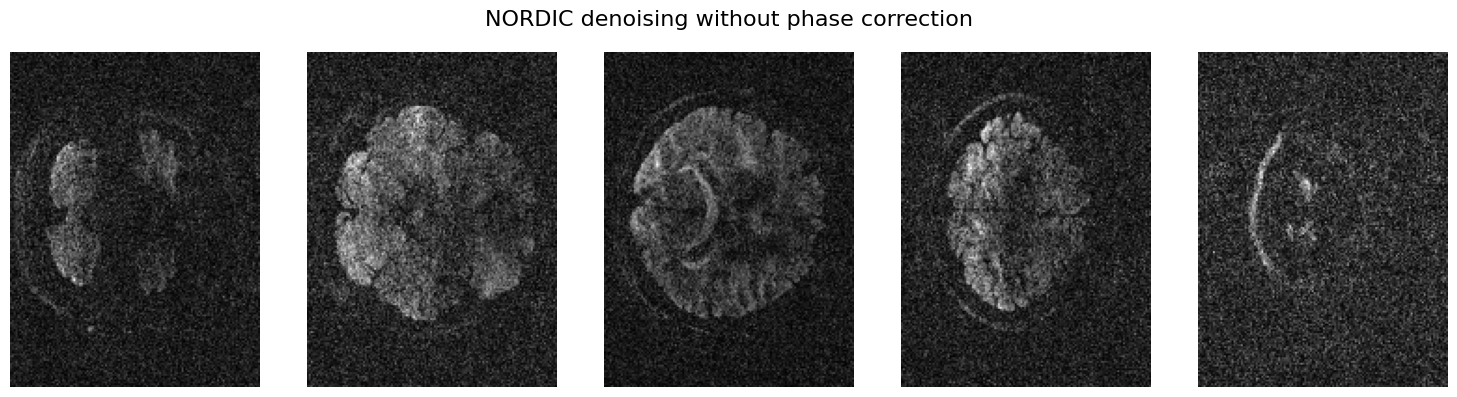

In [10]:
from DC_SENSE import DC_SENSE

# Move to kspace and maps to torch
ksp_list_torch = [torch.from_numpy(x) for x in ksp_list]
maps_torch = torch.from_numpy(maps)

# Create a mask
acceleration_factor = 2
nx, ny = ksp.shape[-2:]
mask = mask_generator(nx, ny, acceleration_factor)
mask = torch.from_numpy(mask).to(torch.complex64)

dc = DC_SENSE()

for x, title in zip(ksp_list_torch, title_list):
    zerofilled = dc.EH(x[q_idx], maps_torch, mask)
    recon = dc(zerofilled, maps_torch, mask, CG_iter = 4) 
    recon = shift_fov(recon, -fov_shifts) #Remove the FOV shifts
    recon = recon.numpy()
    quick_plot(np.abs(recon), gs = (1,5), title = title, fs = 16)

# CG-SPIRIT recons with pre-recon NORDIC

As a comparison, I we can also run CG-SPIRIT instead of CG-SENSE. The number of iterations required  
is usually a bit higher, but we get less noise amplification

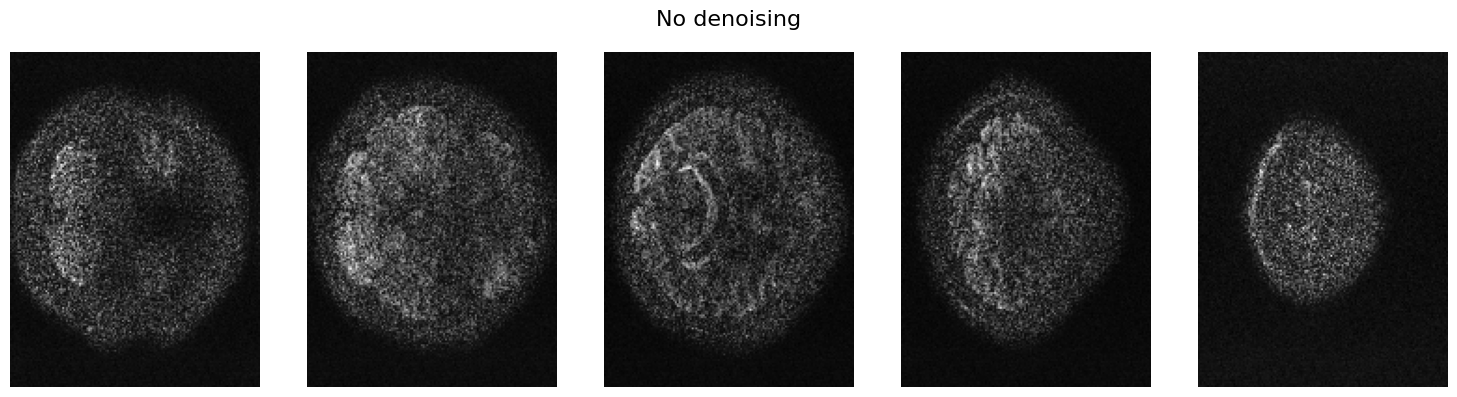

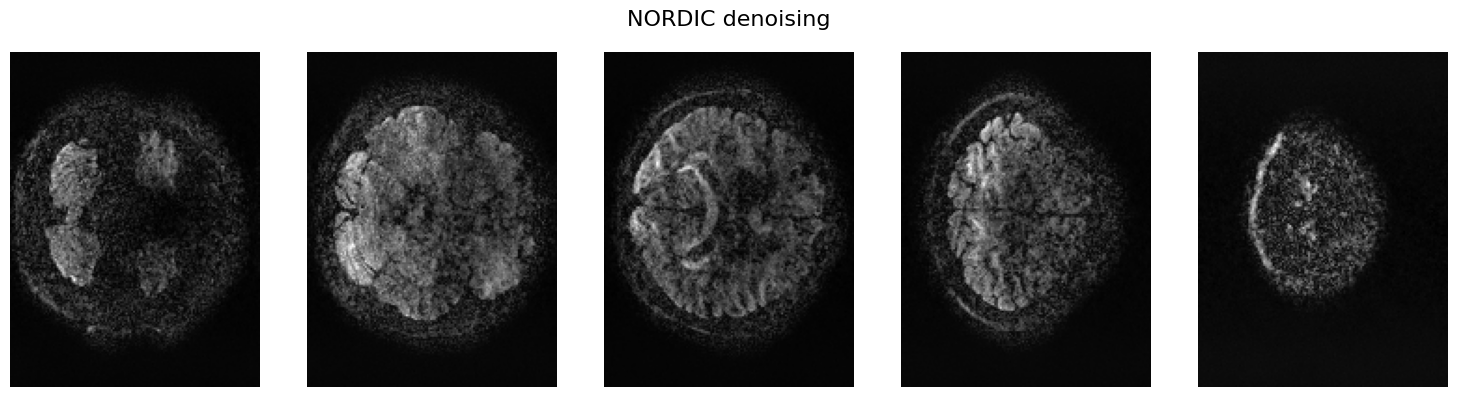

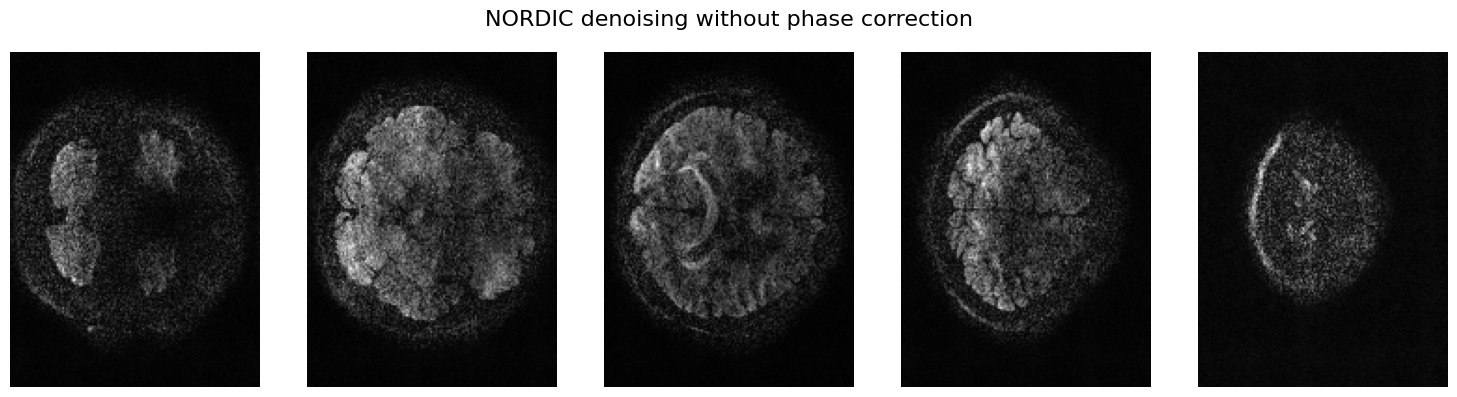

In [11]:
from DC_SPIRIT import DC_SPIRIT

dc = DC_SPIRIT()

spirit_kernels_torch = torch.from_numpy(spirit_kernels)

for x, title in zip(ksp_list_torch, title_list):
    zerofilled = ifft(dc.EH(x[q_idx:q_idx+1], mask))
    recon = dc(zerofilled, spirit_kernels_torch[None], mask, CG_iter = 10) 
    recon = rssq(recon[0])
    recon = shift_fov(recon, -fov_shifts) #Remove the FOV shifts
    recon = recon.numpy()
    quick_plot(np.abs(recon), gs = (1,5), title = title, fs = 16)